## $\chi ^ 2$ Distribution in Linear Regression

In [1]:
import numpy as np
from scipy.special import gamma # Gamma function
from sklearn.linear_model import LinearRegression # For optimized OLS fitting
import pandas as pd
import matplotlib.pyplot as plt

Suppose to have $k$ continuous random variables $x_1, x_2, x_3, \dots, x_k$, independent and normally distributed: $x_j \sim \mathcal{N}(0, 1) $ for each $j$. This sum:

$$
    S = \sum_{j = 1}^{k} \, x_{j}^{2}
$$

It's naturally a continuous random variable itself. It follows a probability density function named $\chi^{2}$:

$$
    \chi^{2}(S;\,k) = \frac{1}{2^{\frac{k}{2}} \, \Gamma \left( \frac{k}{2} \right)} \, S^{\frac{k}{2} - 1} \, e^{- \frac{S}{2}}
$$

$k$ is the number of degrees of freedom of the distribution. Mean and standard deviation of $\chi^{2}$ distribution are:

$$
    \operatorname{Mean}(S) = k \qquad \operatorname{Std}(S) = \sqrt{2 \, k}
$$

In [2]:
def chi2_curve(k): # This function re-creates the chi^2 distribution manually

    gaussian_pdf = lambda S, mu, sigma: np.exp(-0.5 * ((S - mu) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi)) # Gaussian probability density function
    chi2_pdf = lambda S, k: (S ** ((k / 2) - 1)) * np.exp(- S / 2) / (2 ** (k / 2) * gamma(k / 2)) # X^2 probability density function

    S = np.sum(np.random.randn(2_000, k) ** 2, axis = 1) # Computing S by summing up 2000 k normal random variables. It depends on k, the degrees of freedom
    S_mean = np.mean(S) # Mean of S
    S_std = np.std(S) # Standard deviation of S

    # Plot section: histogram and comparison with the known solution
    s = np.linspace(min(S), max(S), 100)
    plt.title(rf"$\chi^2 (S; k = {k})$")
    plt.hist(S, bins = 'auto', density = True, color = 'red', label = "S histogram", alpha = 0.8)
    plt.plot(s, chi2_pdf(s, k), color = 'black', linestyle = '--', linewidth = 1.5, label = rf"$\chi^2 (S; {k})$ pdf")
    if k > 75: # If we have a lot of degrees of freedom, we do an extra comparison with the gaussian curve with mu = k and sigma = sqrt(2k)
        plt.plot(s, gaussian_pdf(s, k, np.sqrt(2 * k)), color = 'gold', linestyle = '--', linewidth = 1.5, label = rf"$N ({k}, {np.sqrt(2 * k):.2f})$")
    plt.xlabel("S")
    plt.ylabel("Probability")

    legend = plt.legend(loc = 'best')
    plt.draw()  # Make sure legend position is computed
    bbox = legend.get_window_extent().transformed(plt.gca().transAxes.inverted()) # Get legend's bounding box in axes coordinates
    textstr = f"Mean = {S_mean:.2f}\nStd = {S_std:.2f}"
    plt.text(bbox.x0 + bbox.width / 2, bbox.y0 - 0.03, textstr, transform = plt.gca().transAxes, horizontalalignment = 'center', verticalalignment = 'top', bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.8))  # Place text centered below the legend

    plt.grid(True, linestyle = '--', color = 'gray', alpha = 0.6)
    plt.show()

    return None

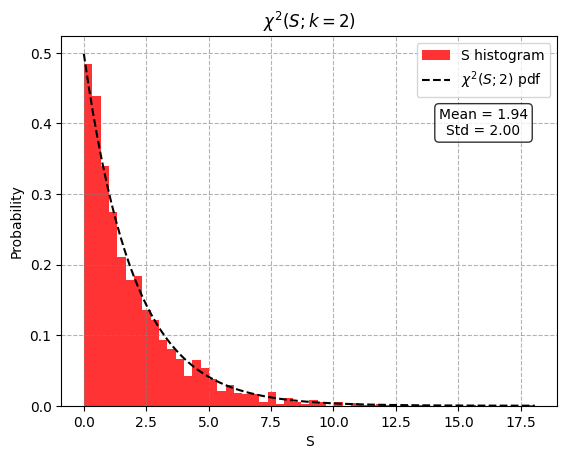

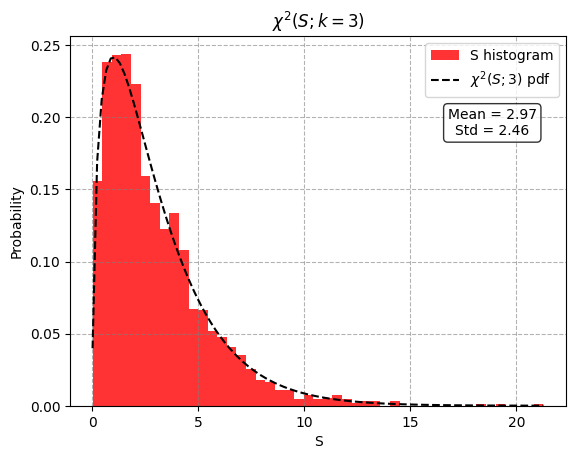

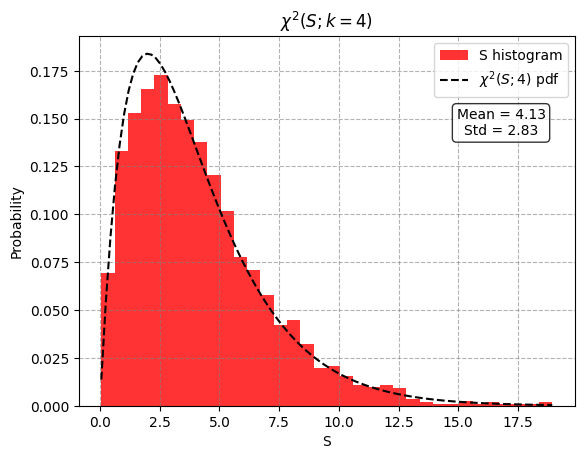

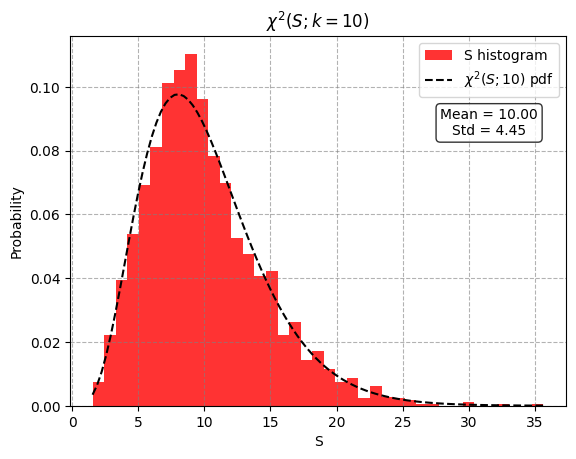

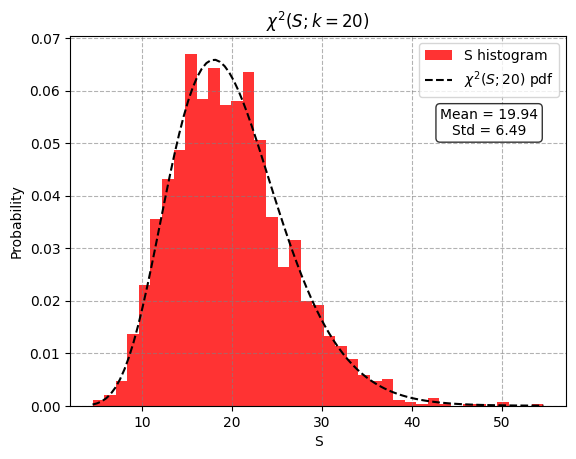

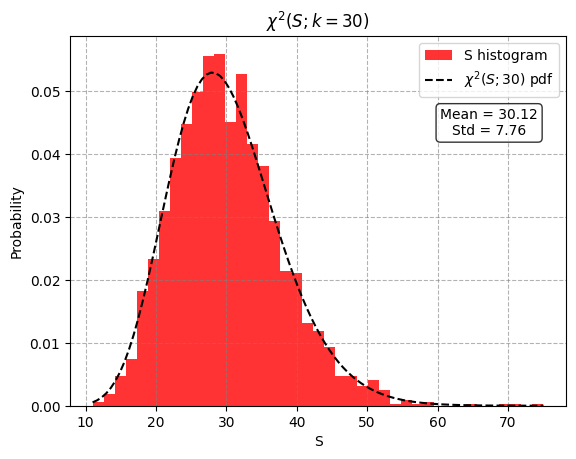

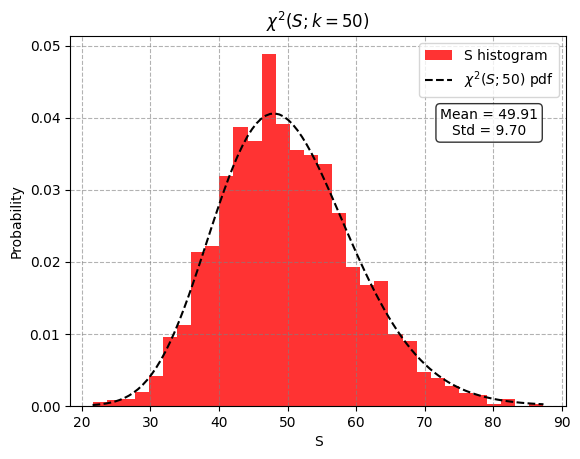

In [3]:
for k in [2, 3, 4, 10, 20, 30, 50]: # Plotting some shapes for different k values
    chi2_curve(k)

As $k \rightarrow + \infty$, the probability density function of $S$ approaches a Gaussian curve, with a mean of $k$ and a standard deviation of $\sqrt{2\,k}$. This result follows directly from the Central Limit Theorem. Its conditions are satisfied because our random variables are independent and identically distributed, and both the mean and standard deviation are well-defined.


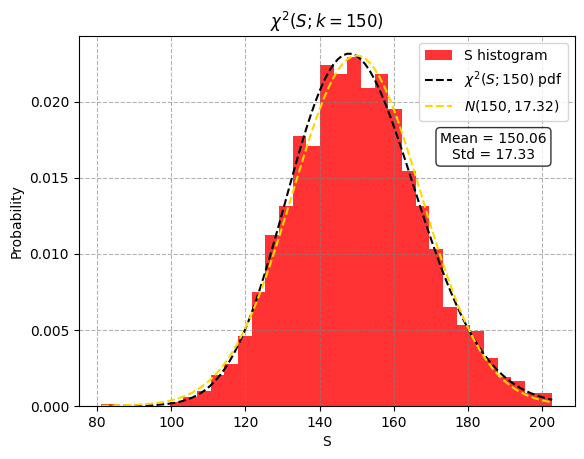

In [4]:
chi2_curve(150) # If k is huge, the pdf of S tends to Gaussian distribution

### Connection to OLS and WLS

This probability density function is important in Least Squares data-fitting problems. Theory (see *Covariance Matrix* file) says that residuals and noise are linked with a linear transformation:

$$
    \boldsymbol{r} = \left( \mathcal{I} - \mathcal{P} \right) \, \boldsymbol{\varepsilon}
$$

Where $\mathcal{P}$ is a symmetric and idempotent matrix: $\mathcal{P} = \mathcal{P} ^ T$ and $\mathcal{P} ^ 2 = \mathcal{P}$. So, we can write the sum of squared residuals only with the noisy vector:

$$
    \text{SSR} = \boldsymbol{\varepsilon} ^ T \, \left( \mathcal{I} - \mathcal{P} \right) \, \boldsymbol{\varepsilon}
$$

Now, we know that $\left( \mathcal{I} - \mathcal{P} \right)$ is an orthogonal projection matrix with rank $n - k$, and eigenvalues of $1$ and $0$ solely. Spectral theorem confirms that it can be diagonalized by an orthogonal matrix $\mathcal{Q}$:

$$
    \mathcal{Q}^{T} \, \left( \mathcal{I} - \mathcal{P} \right) \, \mathcal{Q} = \begin{pmatrix} \mathcal{I}_{n - k} & 0 \\
                                                                                                  0 & 0 \end{pmatrix}
$$

If we define:

$$
    \boldsymbol{z} = \frac{1}{\sigma} \, \boldsymbol{\varepsilon} \quad \rightarrow \quad \frac{\text{SSR}}{\sigma ^ 2} = z^T \, \left( \mathcal{I} - \mathcal{P} \right) \, z = z^T \, \mathcal{Q} \, \begin{pmatrix} \mathcal{I}_{n - k} & 0 \\
                                                                                                                                                                                                                        0 & 0 \end{pmatrix} \, \mathcal{Q}^T \, z
$$

$$
    \boldsymbol{u} = \mathcal{Q}^T \, \boldsymbol{z} \quad \rightarrow \quad \frac{\text{SSR}}{\sigma ^ 2} = \boldsymbol{u}^T \, \begin{pmatrix} \mathcal{I}_{n - k} & 0 \\
                                                                                                                                                 0 & 0 \end{pmatrix} \, \boldsymbol{u} = \sum_{j = 1}^{n - k} \, u_j^2
$$

Since $\boldsymbol{\varepsilon}$ is assumed normally distributed with a mean of zero and a constant standard deviation of $\sigma$, $\boldsymbol{z}$ is normally distributed as well, with a mean of zero and a standard deviation of one. $\mathcal{Q}$ is an orthogonal transformation (a rotation matrix), therefore it doesn't affect the probability density function of $\boldsymbol{z}$. So, $\boldsymbol{u}$ is normally distributed with a mean of zero and a standard deviation of one as well. FInally, we can say the sum of squared residuals divided by $\sigma ^ 2$ follows a $\chi^2$ distribution with $n - k$ degrees of freedom, by definition:

$$
    \frac{\text{SSR}}{\sigma ^ 2} \sim \chi^2_{n - k}
$$

In OLS, $\sigma$ is generally unknown. The best we can do is to estimate it:

$$
    \hat{\sigma}^2 = \frac{\text{SSR}}{n - k}
$$

In WLS, in the specific case we know the true standard deviations of $y_{true}$, the calculation yields the same result with $\sigma = 1$ and the SSR is weighted appropriately:

$$
    \text{SSR} \sim \chi^2_{n-k} \qquad \text{SSR} = \sum_{j = 1}^{N} \, \frac{\left( y_{j} - \hat{y}_j \right) ^ 2}{\sigma_j ^ 2}
$$

In [5]:
dataset = pd.read_csv('headbrain.csv') # Loading a real dataset: head size (x) vs brain weight (y)
dataset

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590
...,...,...,...,...
232,2,2,3214,1110
233,2,2,3394,1215
234,2,2,3233,1104
235,2,2,3352,1170


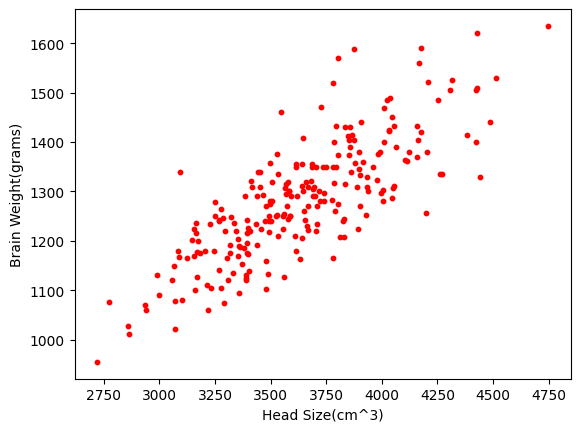

In [6]:
dataset.plot(kind = 'scatter', x = 'Head Size(cm^3)', y = 'Brain Weight(grams)', color = 'red', s = 10) # Visualizing data, fast plot using Pandas capabilities
plt.show()

Let's use scikit-learn to perform a quick linear regression. We define the simplest model $y = m \, x + q$. Let's find the best values of $m$ and $q$

In [7]:
data_fitting = LinearRegression( # LinearRegression is a class
    fit_intercept = True,
    copy_X = True,
    tol = 1e-08,
    n_jobs = None,
    positive = False
)

In [8]:
X = dataset['Head Size(cm^3)'].to_numpy().reshape(- 1, 1) # Reshaping X for LinearRegression
y_true = dataset['Brain Weight(grams)'].to_numpy() # Pull out y_true from the dataset
data_fitting.fit(X, y_true, sample_weight = None) # Fitting process

,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-08
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.26]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,325.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5611.25]


In [9]:
data_fitting.coef_[0], data_fitting.intercept_ # best parameters values (m, q)

(np.float64(0.26342933948939934), np.float64(325.5734210494426))

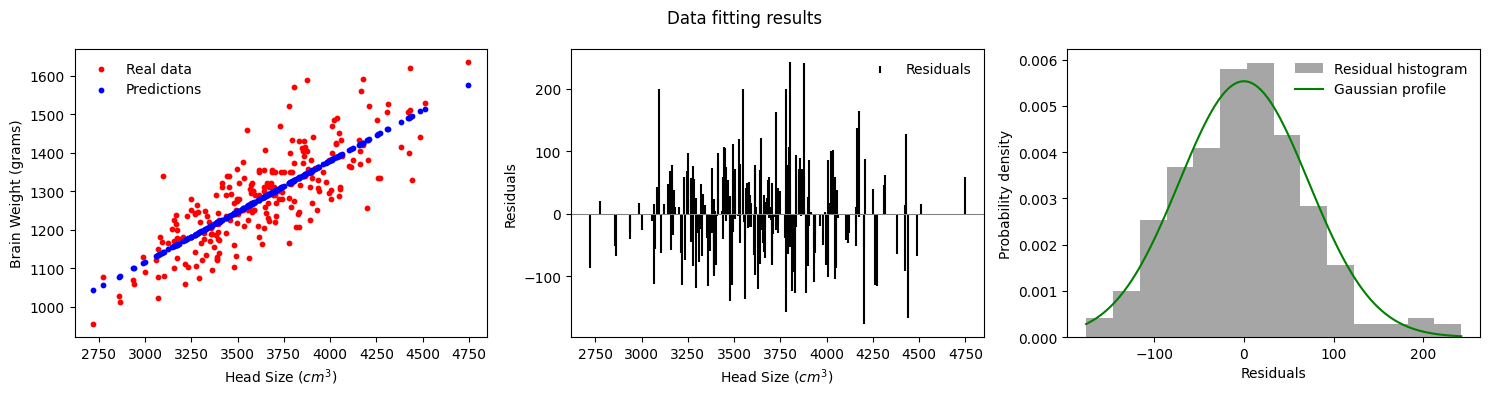

In [10]:
y_pred = data_fitting.predict(X) # Predictions
res = y_true - y_pred # Residuals

res_std = np.std(res) # Standard deviation of residuals

# Plotting results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (15, 4))
fig.suptitle('Data fitting results')

# Scatter plot of real vs predicted
ax1.scatter(X.flatten(), y_true, color = 'red', s = 10, label = 'Real data')
ax1.scatter(X.flatten(), y_pred, color = 'blue', s = 10, label = 'Predictions')
ax1.set_xlabel(r'Head Size ($cm^{3}$)')
ax1.set_ylabel('Brain Weight (grams)')
ax1.legend(loc = 'best', frameon = False)

# Residual impulse plot
ax2.stem(X.flatten(), res, linefmt = 'k-', markerfmt = ' ', basefmt = ' ', label = 'Residuals')
ax2.axhline(0, color = 'gray', lw = 0.75)
ax2.set_xlabel(r'Head Size ($cm^{3}$)')
ax2.set_ylabel('Residuals')
ax2.legend(loc = 'best', frameon = False)

# Residual histogram
gaussian = lambda x, mu, sigma: 1.0 /(np.sqrt(2.0 * np.pi) * sigma) * np.exp(- 0.5 * ((x - mu) / sigma) ** 2)
x_res = np.linspace(min(res), max(res), 100)

ax3.hist(res, density = True, bins = 'auto', alpha = 0.7, color = 'gray', label = 'Residual histogram')
ax3.plot(x_res, gaussian(x_res, 0.0, res_std), 'g-', label = 'Gaussian profile')
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Probability density')
ax3.legend(loc = 'best', frameon = False)

plt.tight_layout()
plt.show()

We can see that the residuals follow a gaussian-like distribution with mean 0 and standard deviation about 72. Let's compare this value with $\hat{\sigma}$

NOTE: residuals do not have the same variance and they are correlated to each other! We'll prove this

In [11]:
np.mean(res), res_std # Mean and standard deviation of residuals

(np.float64(-2.302518232336527e-14), np.float64(72.1206213783709))

In [12]:
SSR = res.dot(res) # Sum of squared residuals
SSR

np.float64(1232728.0146365524)

In [13]:
sigma_hat = np.sqrt(SSR / (len(res) - 2)) # Estimation of sigma, the standard deviation of noise varepsilon in the linear model: y = X * beta + varepsilon
sigma_hat

np.float64(72.42686743269371)

The relationship between the residuals and noise is:

$$
    \boldsymbol{r} = \left( \mathcal{I} - \mathcal{P} \right) \, \boldsymbol{\varepsilon} \qquad \mathcal{P} = \mathcal{X} \, \left( \mathcal{X}^{T} \, \mathcal{X} \right)^{-1} \, \mathcal{X}^{T}
$$

$\mathcal{X}$ is the design matrix, $\mathcal{I}$ the identity matrix.

Since $I - P$ is fixed, we have:

$$
    \operatorname{Mean}(\boldsymbol{r}) = \boldsymbol{0}
$$

$$
    \operatorname{Cov}(\boldsymbol{r}) = \sigma^2 \, \left( \mathcal{I} - \mathcal{P} \right)
$$

In [14]:
design_matrix = np.column_stack((np.ones_like(y_true), X.flatten())) # Design matrix
design_matrix

array([[   1, 4512],
       [   1, 3738],
       [   1, 4261],
       [   1, 3777],
       [   1, 4177],
       [   1, 3585],
       [   1, 3785],
       [   1, 3559],
       [   1, 3613],
       [   1, 3982],
       [   1, 3443],
       [   1, 3993],
       [   1, 3640],
       [   1, 4208],
       [   1, 3832],
       [   1, 3876],
       [   1, 3497],
       [   1, 3466],
       [   1, 3095],
       [   1, 4424],
       [   1, 3878],
       [   1, 4046],
       [   1, 3804],
       [   1, 3710],
       [   1, 4747],
       [   1, 4423],
       [   1, 4036],
       [   1, 4022],
       [   1, 3454],
       [   1, 4175],
       [   1, 3787],
       [   1, 3796],
       [   1, 4103],
       [   1, 4161],
       [   1, 4158],
       [   1, 3814],
       [   1, 3527],
       [   1, 3748],
       [   1, 3334],
       [   1, 3492],
       [   1, 3962],
       [   1, 3505],
       [   1, 4315],
       [   1, 3804],
       [   1, 3863],
       [   1, 4034],
       [   1, 4308],
       [   1,

In [15]:
IP = np.diag(np.ones_like(y_true)) - ((design_matrix @ np.linalg.inv(design_matrix.T @ design_matrix)) @ design_matrix.T) # I - P matrix
IP

array([[ 9.71296850e-01, -7.11974087e-03, -2.17038788e-02, ...,
         6.96245735e-03,  3.64407797e-03,  2.55654187e-03],
       [-7.11974087e-03,  9.95437019e-01, -6.29061077e-03, ...,
        -2.89481098e-03, -3.28790453e-03, -3.41673351e-03],
       [-2.17038788e-02, -6.29061077e-03,  9.83294481e-01, ...,
         3.76584966e-03,  1.39610948e-03,  6.19471944e-04],
       ...,
       [ 6.96245735e-03, -2.89481098e-03,  3.76584966e-03, ...,
         9.90673767e-01, -7.81070965e-03, -7.31402559e-03],
       [ 3.64407797e-03, -3.28790453e-03,  1.39610948e-03, ...,
        -7.81070965e-03,  9.93255060e-01, -6.39565379e-03],
       [ 2.55654187e-03, -3.41673351e-03,  6.19471944e-04, ...,
        -7.31402559e-03, -6.39565379e-03,  9.93905325e-01]],
      shape=(237, 237))

The covariance matrix of residuals divided by $\sigma^2$ should be $\mathcal{I} - \mathcal{P}$. Its diagonal must be an array of values a little bit less that one.

In [16]:
np.diag(IP)

array([0.97129685, 0.99543702, 0.98329448, 0.99513105, 0.9864159 ,
       0.99570436, 0.99505635, 0.99560198, 0.9957666 , 0.99193414,
       0.99462206, 0.99168714, 0.99577944, 0.98531613, 0.99453537,
       0.99392047, 0.99518456, 0.99488429, 0.98655393, 0.97595876,
       0.9938896 , 0.9903893 , 0.99486264, 0.9955971 , 0.9564367 ,
       0.97600891, 0.99064783, 0.99099911, 0.99475166, 0.98648475,
       0.99503704, 0.99494699, 0.98879438, 0.98695964, 0.98705978,
       0.99475147, 0.99541703, 0.99536778, 0.99292235, 0.99514026,
       0.99236355, 0.99525214, 0.98105118, 0.99486264, 0.99411494,
       0.99069878, 0.98135243, 0.98879488, 0.99577903, 0.99577741,
       0.99368274, 0.99497758, 0.98293346, 0.98993522, 0.99124239,
       0.99479689, 0.99369903, 0.98679147, 0.99290294, 0.99574167,
       0.99407102, 0.99393607, 0.9750452 , 0.98361107, 0.99550585,
       0.99282628, 0.99425747, 0.9936006 , 0.97565652, 0.97805783,
       0.99133793, 0.99418688, 0.98824784, 0.99009758, 0.99463

The variance of the residual vector is not constant as said before: each residual follows a gaussian distribution centered at zero and with a standard deviation of a little bit less that $\sigma$. The residuals are correlated because all elements off-diagonal of the covariance matrix aren't zero.

The minimized sum of squared residuals follows:

$$
    \frac{\text{SSR}}{\sigma^{2}} \sim \chi^{2}_{235} \sim \mathcal{N}(\text{mean}=235,\ \text{std}=22)
$$

Now, let's define the total sum of squares:

$$
    \text{SST} = \sum_{j = 1}^{N} \, \left( \boldsymbol{y_j} - \operatorname{Mean}(\boldsymbol{y}) \right) ^ 2
$$

We can compute the coefficient of determination $R ^ 2$, a standardized metric that measures the fraction of the total variance in $y$ that the model explains:

$$
    R ^ 2 = 1 - \frac{SSR}{SST}
$$

In [17]:
R2 = 1 - SSR / np.sum((y_true - np.mean(y_true)) ** 2)
R2, data_fitting.score(X, y_true) # R2 manually computed, and R2 computed by score() method from scikit-learn

(np.float64(0.639311719957), 0.639311719957)